# [Day2] 시계열 데이터 실습미션

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [4]:
os.chdir('/content/drive/MyDrive/Colab Notebooks/05 판다스 넘파이 크롤링 실습/Day_04_file')
os.getcwd()

'/content/drive/MyDrive/Colab Notebooks/05 판다스 넘파이 크롤링 실습/Day_04_file'

In [5]:
stock = pd.read_csv('stock_px.csv')
stock = stock.rename(columns={'Unnamed: 0': 'Date'})

In [20]:
# 데이터 앞부분 확인하기
stock.head()

,Date,AAPL,MSFT,XOM,SPX,date
0,2003-01-02 00:00:00,7.40,21.11,29.22,909.03,2003-01-02
1,2003-01-03 00:00:00,7.45,21.14,29.24,908.59,2003-01-03
2,2003-01-06 00:00:00,7.45,21.52,29.96,929.01,2003-01-06
3,2003-01-07 00:00:00,7.43,21.93,28.95,922.93,2003-01-07
4,2003-01-08 00:00:00,7.28,21.31,28.83,909.93,2003-01-08


In [7]:
# 행과 열 개수 확인하기
stock.shape

(2214, 5)

In [18]:
# 컬럼별 자료형 확인하기
stock.dtypes

,0
Date,object
AAPL,float64
MSFT,float64
XOM,float64
SPX,float64
date,datetime64[ns]


### (2) 날짜형 데이터로 변환

In [22]:
# TODO: Date 컬럼을 날짜형으로 변환하기
stock['Date'] = pd.to_datetime(stock['Date'])

In [23]:
# 변환 결과 확인하기
stock.dtypes

,0
Date,datetime64[ns]
AAPL,float64
MSFT,float64
XOM,float64
SPX,float64
date,datetime64[ns]


In [27]:
# TODO: Date 컬럼에서 연도, 월 정보 추출하기
stock['year'] = stock['Date'].dt.year
stock['month'] = stock['Date'].dt.month

In [28]:
# 추출 결과 확인하기
stock[['Date', 'year', 'month']].head()

,Date,year,month
0,2003-01-02,2003,1
1,2003-01-03,2003,1
2,2003-01-06,2003,1
3,2003-01-07,2003,1
4,2003-01-08,2003,1


### (3) Date를 인덱스로 설정

In [29]:
# 인덱스 확인하기
stock.index

RangeIndex(start=0, stop=2214, step=1)

In [31]:
stock = stock.set_index('Date')

In [32]:
# 앞부분 확인하기
stock.head()

,AAPL,MSFT,XOM,SPX,date,year,month
Date,,,,,,,
2003-01-02,7.40,21.11,29.22,909.03,2003-01-02,2003,1
2003-01-03,7.45,21.14,29.24,908.59,2003-01-03,2003,1
2003-01-06,7.45,21.52,29.96,929.01,2003-01-06,2003,1
2003-01-07,7.43,21.93,28.95,922.93,2003-01-07,2003,1
2003-01-08,7.28,21.31,28.83,909.93,2003-01-08,2003,1


### (4) 특정 기간 선택

In [37]:
# TODO: 2010년 데이터만 선택하기
stock_2010 =stock.loc['2010']

In [38]:
# 선택 결과 확인하기
stock_2010.head()

,AAPL,MSFT,XOM,SPX,date,year,month
Date,,,,,,,
2010-01-04,214.01,29.76,66.16,1132.99,2010-01-04,2010,1
2010-01-05,214.38,29.77,66.42,1136.52,2010-01-05,2010,1
2010-01-06,210.97,29.58,66.99,1137.14,2010-01-06,2010,1
2010-01-07,210.58,29.28,66.78,1141.69,2010-01-07,2010,1
2010-01-08,211.98,29.48,66.52,1144.98,2010-01-08,2010,1


In [39]:
# TODO: 2010년 1월부터 3월까지 선택하기
stock_2010_q1 = stock.loc['2010-01':'2010-03']

In [86]:
# 선택 결과 확인하기
stock_2010_q1.head()

,AAPL,MSFT,XOM,SPX,date,year,month
Date,,,,,,,
2010-01-04,214.01,29.76,66.16,1132.99,2010-01-04,2010,1
2010-01-05,214.38,29.77,66.42,1136.52,2010-01-05,2010,1
2010-01-06,210.97,29.58,66.99,1137.14,2010-01-06,2010,1
2010-01-07,210.58,29.28,66.78,1141.69,2010-01-07,2010,1
2010-01-08,211.98,29.48,66.52,1144.98,2010-01-08,2010,1


### (5) 월별 평균 종가 계산

In [49]:
# TODO: AAPL의 월별 평균 종가 계산하기
monthly_aapl = stock['AAPL'].resample('ME').mean()
monthly_aapl

,AAPL
Date,
2003-01-31,7.239048
2003-02-28,7.333684
2003-03-31,7.299048
2003-04-30,6.923810
2003-05-31,8.885238
...,...
2011-06-30,331.081364
2011-07-31,372.238000
2011-08-31,376.762609


In [50]:
# 월별 평균 종가 확인하기
monthly_aapl.head()

,AAPL
Date,
2003-01-31,7.239048
2003-02-28,7.333684
2003-03-31,7.299048
2003-04-30,6.923810
2003-05-31,8.885238


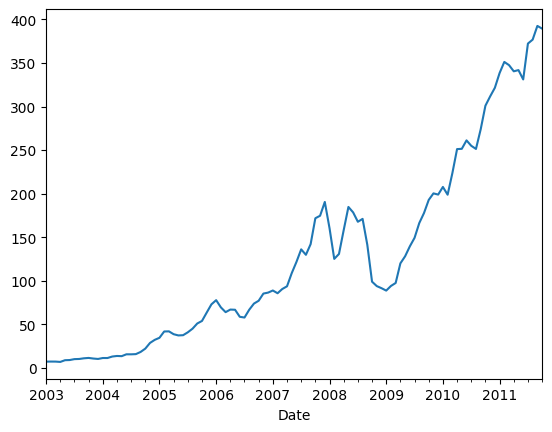

In [56]:
# TODO: 월별 평균 종가 그래프 그리기
monthly_aapl.plot()
plt.show()


### (6) 분기별 데이터 확인

In [57]:
# TODO: AAPL의 분기별 평균 종가 계산하기

quarterly_aapl = stock['AAPL'].resample('QE').mean()

In [58]:
# 분기별 종가 확인하기
quarterly_aapl.head()

,AAPL
Date,
2003-03-31,7.289180
2003-06-30,8.299365
2003-09-30,10.499844
2003-12-31,10.893906
2004-03-31,12.031613


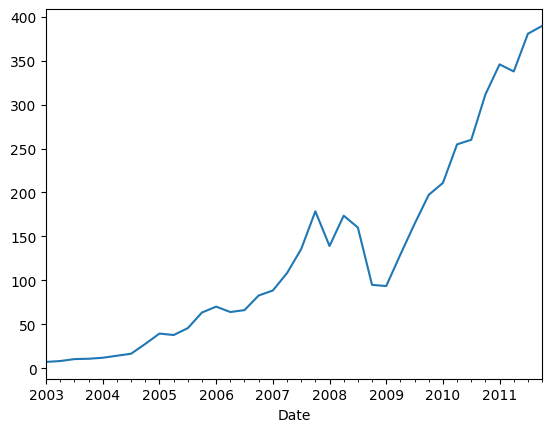

In [59]:
# TODO: 분기별 종가 그래프 그리기
quarterly_aapl.plot()
plt.show()

### (7) 이동평균 계산

In [64]:
# TODO: AAPL의 20일 이동평균 계산하기
stock['AAPL_ma20'] = stock['AAPL'].rolling(window=20).mean()

In [65]:
# 이동평균 결과 확인하기
stock[['AAPL', 'AAPL_ma20']].head(25)

,AAPL,AAPL_ma20
Date,,
2003-01-02,7.40,NaN
2003-01-03,7.45,NaN
2003-01-06,7.45,NaN
2003-01-07,7.43,NaN
2003-01-08,7.28,NaN
2003-01-09,7.34,NaN
2003-01-10,7.36,NaN
2003-01-13,7.32,NaN
2003-01-14,7.30,NaN


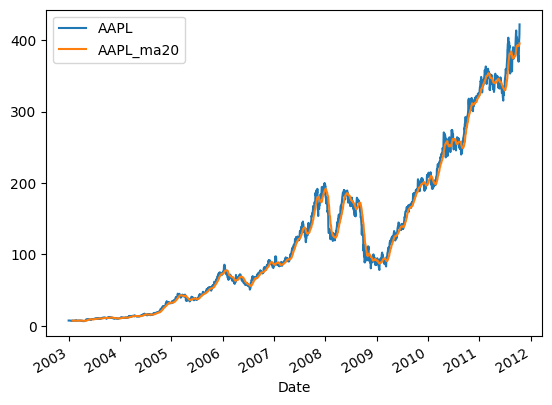

In [66]:
# TODO: AAPL 종가와 20일 이동평균 그래프 그리기

stock[['AAPL', 'AAPL_ma20']].plot()
plt.show()

### 선택 미션

기본 미션을 마친 뒤 진행합니다. 예제코드북에서 다룬 `loc`, `resample`, `rolling`, `plot`을 다시 활용합니다.


#### (1) MSFT의 월별 평균 종가 계산

In [67]:
# TODO: MSFT의 월별 평균 종가 계산하기
monthly_msft = stock['AAPL'].resample('ME').mean()
monthly_msft

,AAPL
Date,
2003-01-31,7.239048
2003-02-28,7.333684
2003-03-31,7.299048
2003-04-30,6.923810
2003-05-31,8.885238
...,...
2011-06-30,331.081364
2011-07-31,372.238000
2011-08-31,376.762609


In [68]:
# 월별 평균 종가 확인하기
monthly_msft.head()

,AAPL
Date,
2003-01-31,7.239048
2003-02-28,7.333684
2003-03-31,7.299048
2003-04-30,6.923810
2003-05-31,8.885238


#### (2) XOM의 월별 평균 종가 계산

In [69]:
# TODO: XOM의 월별 평균 종가 계산하기
monthly_xom = stock['XOM'].resample('ME').mean()
monthly_xom

,XOM
Date,
2003-01-31,28.356190
2003-02-28,27.985263
2003-03-31,29.065238
2003-04-30,29.050476
2003-05-31,29.728571
...,...
2011-06-30,79.365909
2011-07-31,82.196500
2011-08-31,73.058696


In [70]:
# 월별 평균 종가 확인하기
monthly_xom.head()

,XOM
Date,
2003-01-31,28.356190
2003-02-28,27.985263
2003-03-31,29.065238
2003-04-30,29.050476
2003-05-31,29.728571


#### (3) 세 종목의 월별 평균 종가 비교

In [72]:
# TODO: AAPL, MSFT, XOM의 월별 평균 종가 계산하기
monthly_prices = stock[['AAPL','MSFT','XOM']].resample('ME').mean()

In [73]:
# 세 종목의 월별 평균 종가 확인하기
monthly_prices.head()

,AAPL,MSFT,XOM
Date,,,
2003-01-31,7.239048,20.742381,28.356190
2003-02-28,7.333684,18.786316,27.985263
2003-03-31,7.299048,19.395238,29.065238
2003-04-30,6.923810,19.871429,29.050476
2003-05-31,8.885238,19.946667,29.728571


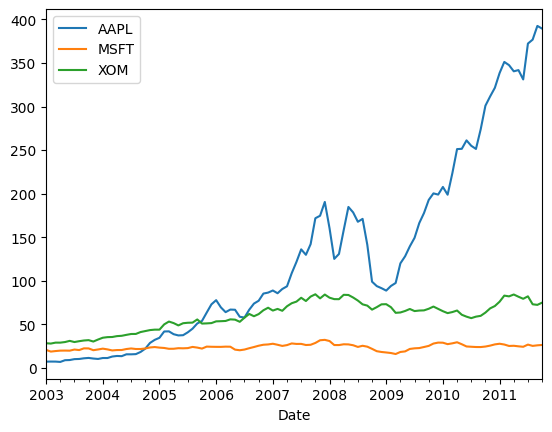

In [74]:
# TODO: 세 종목의 월별 평균 종가 그래프 그리기
monthly_prices.plot()
plt.show()

#### (4) AAPL의 60일 이동평균 추가

In [75]:
# TODO: AAPL의 60일 이동평균 계산하기
stock['AAPL_ma60'] = stock['AAPL'].rolling(window=60).mean()

In [76]:
# 이동평균 결과 확인하기
stock[['AAPL', 'AAPL_ma20', 'AAPL_ma60']].head(65)

,AAPL,AAPL_ma20,AAPL_ma60
Date,,,
2003-01-02,7.40,NaN,NaN
2003-01-03,7.45,NaN,NaN
2003-01-06,7.45,NaN,NaN
2003-01-07,7.43,NaN,NaN
2003-01-08,7.28,NaN,NaN
...,...,...,...
2003-03-31,7.07,7.2980,7.287333
2003-04-01,7.08,7.2880,7.281167
2003-04-02,7.30,7.2875,7.278667


#### (5) AAPL, 20일 이동평균, 60일 이동평균 함께 그리기

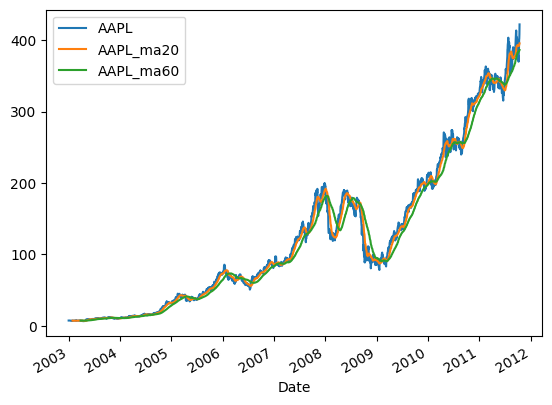

In [77]:
# TODO: AAPL, 20일 이동평균, 60일 이동평균 그래프 그리기
stock[['AAPL', 'AAPL_ma20', 'AAPL_ma60']].plot()
plt.show()

#### (6) 2011년 데이터만 선택해서 AAPL 그래프 그리기

In [80]:
# TODO: 2011년 데이터만 선택하기
stock_2011 = stock.loc['2011']

In [81]:
# 선택 결과 확인하기
stock_2011.head()

,AAPL,MSFT,XOM,SPX,date,year,month,AAPL_ma20,AAPL_ma60
Date,,,,,,,,,
2011-01-03,329.57,27.46,73.26,1271.87,2011-01-03,2011,1,322.5135,313.945333
2011-01-04,331.29,27.57,73.60,1270.20,2011-01-04,2011,1,323.0705,314.565667
2011-01-05,334.00,27.48,73.40,1276.56,2011-01-05,2011,1,323.8600,315.209667
2011-01-06,333.73,28.29,73.88,1273.85,2011-01-06,2011,1,324.4960,315.796167
2011-01-07,336.12,28.07,74.28,1271.50,2011-01-07,2011,1,325.3140,316.395833


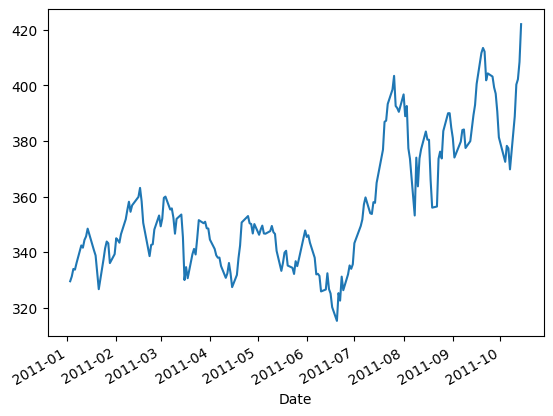

In [84]:
# TODO: 2011년 AAPL 종가 그래프 그리기
stock_2011_AAPL = stock_2011['AAPL']
stock_2011_AAPL.plot()
plt.show()